In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from pathlib import Path
import cv2
import random
import matplotlib.pyplot as plt
from tqdm import tqdm

# ============================================================================
# CONFIGURATION
# ============================================================================

CONFIG = {
    'good_dir': r'D:\_Dataset\M6_29Sep2023\Good',
    'bad_dir': r'D:\_Dataset\M6_29Sep2023\Bad',
    'img_size': (500, 500),
    'batch_size': 8,
    'epochs': 50,
    'learning_rate': 1e-4,
    'model_save_path': 'models/cnn_augmented_500px.pth',
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

device = torch.device(CONFIG['device'])
print(f"Using device: {device}")

Using device: cuda


In [2]:
# ============================================================================
# MULTI-PATH CNN ARCHITECTURE
# ============================================================================

class QualityNet(nn.Module):
    def __init__(self):
        super(QualityNet, self).__init__()
        
        # 10 Parallel Paths with diverse Kernel/Dilation combinations
        # We use padding='same' to keep output dimensions consistent across kernels
        self.paths = nn.ModuleList([
            self._conv_block(3, 32, k=3, d=1),  # Path 0: Standard 3x3
            self._conv_block(3, 32, k=3, d=2),  # Path 1: Dilated (Small textures)
            self._conv_block(3, 32, k=5, d=1),  # Path 2: Medium 5x5
            self._conv_block(3, 32, k=5, d=2),  # Path 3: Dilated Medium
            self._conv_block(3, 32, k=7, d=1),  # Path 4: Large 7x7 (Structural)
            self._conv_block(3, 32, k=7, d=2),  # Path 5: Dilated Large
            self._conv_block(3, 32, k=1, d=1),  # Path 6: 1x1 (Color/Contrast)
            self._conv_block(3, 32, k=3, d=4),  # Path 7: Super Dilated (Wide)
            self._conv_block(3, 32, k=9, d=1),  # Path 8: Extra Large 9x9
            self._conv_block(3, 32, k=5, d=3)   # Path 9: Mixed Scale
        ])
        
        # Buffer to track signal strength for analysis
        self.register_buffer('path_importance', torch.zeros(10))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 10 * 4 * 4, 256), # Updated input size
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def _conv_block(self, in_ch, out_ch, k, d):
        return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=k, padding='same', dilation=d),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        # Add a second conv to give the path more "reasoning" power
        nn.Conv2d(out_ch, out_ch, kernel_size=3, padding='same'),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.AdaptiveAvgPool2d((4, 4)) # Keep some spatial structure
    )

    def forward(self, x, track_importance=False):
        path_outputs = []
        for i, path in enumerate(self.paths):
            out = path(x)
            path_outputs.append(out)
            
            if track_importance:
                # Accumulate absolute mean activation as a proxy for 'usage'
                self.path_importance[i] += out.abs().mean().detach()
        
        # Concatenate 10 paths * 32 channels = 320 features
        x_combined = torch.cat(path_outputs, dim=1)
        return self.classifier(x_combined)

# ============================================================================
# PATH ANALYSIS VISUALIZATION
# ============================================================================

def analyze_paths(model):
    paths_desc = [
        "3x3 Std", "3x3 Dil", "5x5 Std", "5x5 Dil", 
        "7x7 Std", "7x7 Dil", "1x1 Color", "3x3 Wide-D", 
        "9x9 Huge", "5x5 Mix"
    ]
    
    importance = model.path_importance.cpu().numpy()
    if importance.sum() == 0: return # Avoid div by zero
    importance = (importance / importance.sum()) * 100

    plt.figure(figsize=(12, 5))
    plt.bar(paths_desc, importance, color='teal', alpha=0.7)
    plt.title("Kernel Path Importance (%)")
    plt.ylabel("Relative Signal Strength")
    plt.xticks(rotation=45)
    plt.show()

In [15]:
# ============================================================================
# DATASET
# ============================================================================

class ImageDataset(Dataset):
    def __init__(self, image_paths, labels, img_size, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.img_size = img_size
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size[1], self.img_size[0]))
        
        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)
            
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label

# ============================================================================
# MAIN TRAINING LOOP
# ============================================================================

def get_data():
    valid_ext = {'.jpg', '.jpeg', '.png', '.bmp'}
    
    def get_files(directory, label):
        p = [str(f) for f in Path(directory).glob('*') if f.suffix.lower() in valid_ext]
        return p, [label] * len(p)

    g_paths, g_labels = get_files(CONFIG['good_dir'], 1)
    b_paths, b_labels = get_files(CONFIG['bad_dir'], 0)
    
    return train_test_split(g_paths + b_paths, g_labels + b_labels, test_size=0.2, random_state=42)

def main():
    train_p, val_p, train_l, val_l = get_data()
    
    # ImageNet normalization helps convergence
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    train_ds = ImageDataset(train_p, train_l, CONFIG['img_size'], transform)
    val_ds = ImageDataset(val_p, val_l, CONFIG['img_size'], transform)

    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'])

    model = QualityNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4) # Use low LR for Multi-Path
    criterion = nn.BCELoss()
    
    print(f"Training on {len(train_ds)} images at {CONFIG['img_size']} resolution...")

    best_val_acc = 0

    for epoch in range(CONFIG['epochs']):
        model.train()
        train_loss = 0
        for imgs, lbls in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            imgs, lbls = imgs.to(device), lbls.to(device).unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, lbls in val_loader:
                # Set track_importance=True during validation pass
                out = model(imgs.to(device), track_importance=True) 
                all_preds.extend((out > 0.5).float().cpu().numpy())
                all_labels.extend(lbls.numpy())
        
        acc = accuracy_score(all_labels, all_preds)
        avg_loss = train_loss / len(train_loader)
        print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Val Acc: {acc:.4f}")
        
        # Save best model
        if acc > best_val_acc:
            best_val_acc = acc
            torch.save(model.state_dict(), CONFIG['model_save_path'])
            print(f"  --> New best accuracy! Model saved.")

    print("\nTraining Complete. Analyzing Path Importance...")
    analyze_paths(model)

Training on 480 images at (500, 500) resolution...


Epoch 1: 100%|██████████| 60/60 [09:20<00:00,  9.34s/it]


Epoch 1 | Loss: 0.7163 | Val Acc: 0.4833
  --> New best accuracy! Model saved.


Epoch 2: 100%|██████████| 60/60 [09:12<00:00,  9.21s/it]


Epoch 2 | Loss: 0.7121 | Val Acc: 0.5167
  --> New best accuracy! Model saved.


...

Epoch 48 | Loss: 0.0769 | Val Acc: 1.0000


Epoch 49: 100%|██████████| 60/60 [10:46<00:00, 10.77s/it]


Epoch 49 | Loss: 0.0665 | Val Acc: 1.0000


Epoch 50: 100%|██████████| 60/60 [10:42<00:00, 10.70s/it]


Epoch 50 | Loss: 0.0578 | Val Acc: 1.0000

Training Complete. Analyzing Path Importance...


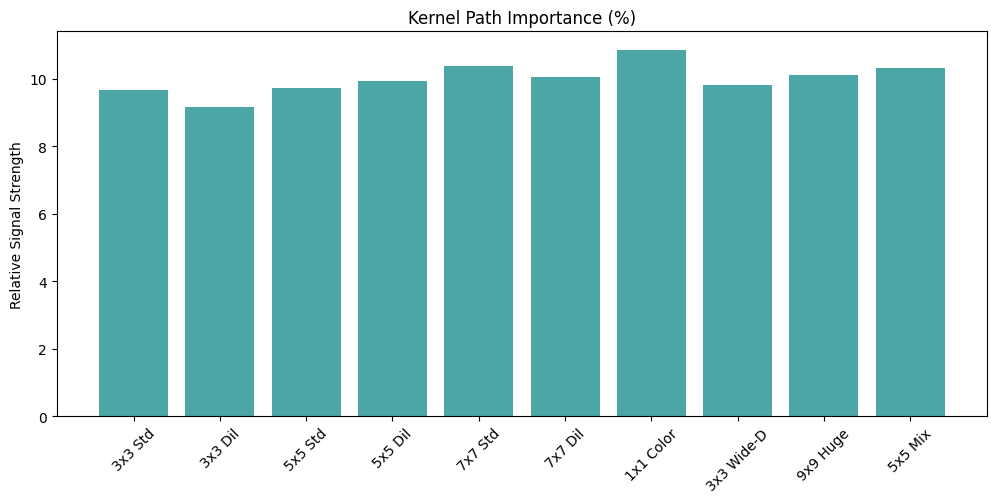

In [16]:
if __name__ == '__main__':
    main()